<div style="pointer-events: none; user-select: none;">
  Prepared By TAUFIQ MUSTAFIZUR RAHMAN

---
</div>


**Task:**

The problem presented is the Traveling Salesman Problem (TSP). You are given five cities—A, B, C, D, and E along with a matrix showing the distances between each of them. The objective is to find the shortest possible route that visits every city exactly once and then returns to the starting point.

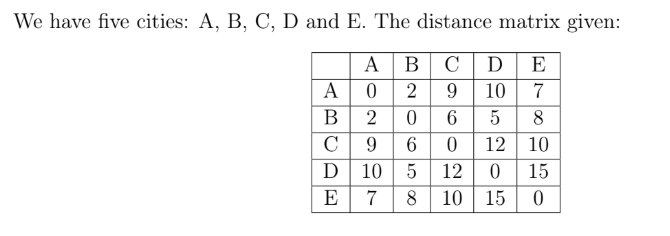

In [8]:
import random

def calculate_distance(route):
    dist = 0
    for i in range(len(route) - 1):
        dist += distances[route[i]][route[i+1]]
    dist += distances[route[-1]][route[0]]
    return dist

def calculate_fitness(route):
    return 1.0 / calculate_distance(route)

def init_population(pop_size):
    population = []
    for _ in range(pop_size):
        route = cities.copy()
        random.shuffle(route)
        population.append(route)
    return population

def selection(population, num_to_select):
    sorted_pop = sorted(population, key=calculate_fitness, reverse=True)
    return sorted_pop[:num_to_select]

def crossover(parent1, parent2):
    start, end = sorted(random.sample(range(len(cities)), 2))
    child = [None] * len(cities)
    child[start:end] = parent1[start:end]
    p2_idx = 0
    for i in range(len(cities)):
        if child[i] is None:
            while parent2[p2_idx] in child:
                p2_idx += 1
            child[i] = parent2[p2_idx]

    return child


def mutate(route, mutation_rate=0.2):
    if random.random() < mutation_rate:
        idx1, idx2 = random.sample(range(len(cities)), 2)
        route[idx1], route[idx2] = route[idx2], route[idx1]
    return route

def genetic_algorithm(generations=50, pop_size=10):
    population = init_population(pop_size)
    best_route = None
    best_distance = float('inf')

    for gen in range(generations):
        # Keep track of the "best-so-far"
        current_best = max(population, key=calculate_fitness)
        current_dist = calculate_distance(current_best)
        if current_dist < best_distance:
            best_distance = current_dist
            best_route = current_best.copy()
        # Keep the top 50% of the population to act as parents
        parents = selection(population, pop_size // 2)

        new_population = parents.copy() # Carry over the best parents (Elitism)

        while len(new_population) < pop_size:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_population.append(child)

        population = new_population

    return best_route, best_distance

cities = ['A', 'B', 'C', 'D', 'E']
distances = {
    'A': {'A': 0,  'B': 2,  'C': 9,  'D': 10, 'E': 7},
    'B': {'A': 2,  'B': 0,  'C': 6,  'D': 5,  'E': 8},
    'C': {'A': 9,  'B': 6,  'C': 0,  'D': 12, 'E': 10},
    'D': {'A': 10, 'B': 5,  'C': 12, 'D': 0,  'E': 15},
    'E': {'A': 7,  'B': 8,  'C': 10, 'D': 15, 'E': 0}
}


best_route, best_dist = genetic_algorithm(generations=50, pop_size=10)
print(f"Optimal Route Found: {' -> '.join(best_route)} -> {best_route[0]}")
print(f"Total Distance: {best_dist}")
print(f"Fitness Score: {1.0/best_dist:.4f}")

Optimal Route Found: D -> C -> E -> A -> B -> D
Total Distance: 36
Fitness Score: 0.0278


**Task:**

[Problem Statement](https://docs.google.com/document/d/1Il3gRVe7lRK6X6s_oqWAmC1AyYb6-Kvoo_wPy1kFiZ0/edit?usp=drive_link)

In this problem, we aim to simulate a simplified version of VLSI floorplanning within a chip circuit, a design challenge often found in the electrical chip manufacturing industry. Your objective is to determine the most optimal placement of 6 common chip components on a 2D chip grid, minimizing both wire length (that interconnects certain components) and the overall required chip area, while avoiding overlapping chip components. Your task is to design a suitable chip layout optimizer using what you have been taught in your Genetic Algorithm class.



In [1]:
import random
import math

BLOCKS = [
    {"name": "ALU", "w": 5, "h": 5},             # 0
    {"name": "Cache", "w": 7, "h": 4},           # 1
    {"name": "Control Unit", "w": 4, "h": 4},    # 2
    {"name": "Register File", "w": 6, "h": 6},   # 3
    {"name": "Decoder", "w": 5, "h": 3},         # 4
    {"name": "Floating Unit", "w": 5, "h": 5}    # 5
]

# Required wiring connections between block indices
CONNECTIONS = [
    (3, 0),  # Register File -> ALU
    (2, 0),  # Control Unit -> ALU[cite: 1]
    (0, 1),  # ALU -> Cache[cite: 1]
    (3, 5),  # Register File -> Floating Unit[cite: 1]
    (1, 4),  # Cache -> Decoder[cite: 1]
    (4, 5)   # Decoder -> Floating Unit[cite: 1]
]

GRID_SIZE = 25
POPULATION_SIZE = 6
GENERATIONS = 15
MUTATION_RATE = 0.1

def generate_chromosome():
    """Generates a random layout of 6 blocks (12 integers: x, y for each block)."""
    return [random.randint(0, GRID_SIZE) for _ in range(len(BLOCKS) * 2)]

def calculate_center(x, y, w, h):
    """Returns the center point of a block for wiring distance calculation."""
    return (x + w / 2, y + h / 2)

def check_overlap(x1, y1, w1, h1, x2, y2, w2, h2):
    """Checks if two blocks overlap using bottom-left coordinates and dimensions."""
    not_overlap = (
        (x1 + w1 <= x2) or # A_right <= B_left
        (x1 >= x2 + w2) or # A_left >= B_right
        (y1 >= y2 + h2) or # A_bottom >= B_top
        (y1 + h1 <= y2)    # A_top <= B_bottom
    )
    return not not_overlap

def evaluate_fitness(chrom):
    """Calculates fitness based on overlaps, wiring distance, and bounding area."""
    coords = [(chrom[i], chrom[i+1]) for i in range(0, len(chrom), 2)]

    # 1. Calculate Overlaps (Heavy Penalty)
    overlap_count = 0
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            x1, y1 = coords[i]
            w1, h1 = BLOCKS[i]["w"], BLOCKS[i]["h"]
            x2, y2 = coords[j]
            w2, h2 = BLOCKS[j]["w"], BLOCKS[j]["h"]
            if check_overlap(x1, y1, w1, h1, x2, y2, w2, h2):
                overlap_count += 1

    # 2. Calculate Total Wiring Distance
    total_distance = 0
    for block_a, block_b in CONNECTIONS:
        xa, ya = coords[block_a]
        wa, ha = BLOCKS[block_a]["w"], BLOCKS[block_a]["h"]
        xb, yb = coords[block_b]
        wb, hb = BLOCKS[block_b]["w"], BLOCKS[block_b]["h"]

        ca_x, ca_y = calculate_center(xa, ya, wa, ha)
        cb_x, cb_y = calculate_center(xb, yb, wb, hb)

        distance = math.sqrt((ca_x - cb_x)**2 + (ca_y - cb_y)**2)
        total_distance += distance

    # 3. Calculate Bounding Box Area
    min_x = min([c[0] for c in coords])
    min_y = min([c[1] for c in coords])
    max_x = max([coords[i][0] + BLOCKS[i]["w"] for i in range(len(coords))])
    max_y = max([coords[i][1] + BLOCKS[i]["h"] for i in range(len(coords))])

    area = (max_x - min_x) * (max_y - min_y)

    # Fitness formula based on problem statement
    alpha, beta, gamma = 1000, 2, 1
    fitness = -(alpha * overlap_count + beta * total_distance + gamma * area)

    return fitness, overlap_count, total_distance, area

# --- 3. Genetic Algorithm Operators ---
def single_point_crossover(p1, p2):
    """Task 1: Single-point crossover."""
    split = random.randint(1, len(p1) - 1)
    c1 = p1[:split] + p2[split:]
    c2 = p2[:split] + p1[split:]
    return c1, c2

def two_point_crossover(p1, p2):
    """Task 2: Two-point crossover."""
    pt1 = random.randint(1, len(p1) - 2)
    pt2 = random.randint(pt1 + 1, len(p1) - 1) # Ensure second point comes after first

    c1 = p1[:pt1] + p2[pt1:pt2] + p1[pt2:]
    c2 = p2[:pt1] + p1[pt1:pt2] + p2[pt2:]
    return c1, c2

def mutate(chrom):
    """Randomly alters the x and y of one specific block."""
    if random.random() < MUTATION_RATE:
        block_idx = random.randint(0, len(BLOCKS) - 1)
        # Apply random change within grid bounds
        chrom[block_idx * 2] = random.randint(0, GRID_SIZE)
        chrom[block_idx * 2 + 1] = random.randint(0, GRID_SIZE)
    return chrom

# --- 4. Main GA Loop ---
def run_ga():
    population = [generate_chromosome() for _ in range(POPULATION_SIZE)]
    best_overall = None
    best_fitness = -float('inf')
    best_metrics = {}

    for gen in range(GENERATIONS):
        # Evaluate fitness
        scored_pop = []
        for chrom in population:
            fit, overlaps, dist, area = evaluate_fitness(chrom)
            scored_pop.append((fit, chrom, overlaps, dist, area))

        # Sort by fitness (highest is best, closer to 0)
        scored_pop.sort(key=lambda x: x[0], reverse=True)

        # Track best
        if scored_pop[0][0] > best_fitness:
            best_fitness = scored_pop[0][0]
            best_overall = scored_pop[0][1]
            best_metrics = {"overlaps": scored_pop[0][2], "dist": scored_pop[0][3], "area": scored_pop[0][4]}

        # Elitism: carry forward top 2
        new_population = [scored_pop[0][1], scored_pop[1][1]]

        # Generate rest of population
        while len(new_population) < POPULATION_SIZE:
            # Random parent selection
            p1 = random.choice(population)
            p2 = random.choice(population)

            # Use Task 2's Two-point crossover as requested
            c1, c2 = two_point_crossover(p1, p2)

            # Mutate and add
            new_population.append(mutate(c1))
            if len(new_population) < POPULATION_SIZE:
                new_population.append(mutate(c2))

        population = new_population


    print("--- Optimal Layout Found ---")
    print(f"Total Fitness Value: {best_fitness:.2f}")
    print(f"Total Wiring Length: {best_metrics['dist']:.2f}")
    print(f"Total Bounding Area: {best_metrics['area']}")
    print(f"Total Overlap Count: {best_metrics['overlaps']}")

    print("\n--- Decoded Bottom-Left Coordinates ---")
    for i in range(len(BLOCKS)):
        x, y = best_overall[i*2], best_overall[i*2+1]
        print(f"{BLOCKS[i]['name']}: ({x}, {y})")

run_ga()

--- Optimal Layout Found ---
Total Fitness Value: -813.34
Total Wiring Length: 84.67
Total Bounding Area: 644
Total Overlap Count: 0

--- Decoded Bottom-Left Coordinates ---
ALU: (5, 13)
Cache: (16, 19)
Control Unit: (10, 13)
Register File: (2, 25)
Decoder: (0, 16)
Floating Unit: (7, 3)
